# Excess Free Energy Plot

Demonstrates `plot_excess_free_energy` with a system analogous to the one in
`Intermetallics.ipynb`, extended with an additional `FastInterpolatingPhase` to
show how the function handles a mix of phase types.

The excess free energy is defined relative to a linear reference connecting
the lowest-energy phases at c = 0 and c = 1.  The DataFrame is built explicitly
via `calc_phase_diagram` before being passed to `plot_excess_free_energy`.

## Prelude

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from scipy.constants import Boltzmann, eV
kB = Boltzmann / eV

from landau.phases import LinePhase, IdealSolution, FastInterpolatingPhase
from landau.calculate import calc_phase_diagram
from landau import plot_excess_free_energy

## Phase Setup

Same solid, liquid, and AB$_2$ intermetallic as in `Intermetallics.ipynb`, plus a
`FastInterpolatingPhase` modelling a sigma-like phase built from five ab-initio
data points covering c ∈ [0.3, 0.7].

| Phase   | Type                     | c range    | Description                  |
|---------|--------------------------|------------|------------------------------|
| solid   | `IdealSolution`          | [0, 1]     | A-B solid solution           |
| liquid  | `IdealSolution`          | [0, 1]     | A-B liquid                   |
| AB$_2$    | `LinePhase`              | c = 2/3    | Ordered intermetallic        |
| sigma   | `FastInterpolatingPhase` | [0.3, 0.7] | Sigma-like phase (ab-initio) |

In [2]:
solid_a = LinePhase('A',     fixed_concentration=0, line_energy=-2.0, line_entropy=1.0*kB)
solid_b = LinePhase('B',     fixed_concentration=1, line_energy=-3.0, line_entropy=1.5*kB)
solid   = IdealSolution('solid', solid_a, solid_b)

liquid_a = LinePhase('A(l)', fixed_concentration=0, line_energy=-1.9, line_entropy=2.5*kB)
liquid_b = LinePhase('B(l)', fixed_concentration=1, line_energy=-2.9, line_entropy=2.2*kB)
liquid   = IdealSolution('liquid', liquid_a, liquid_b)

inter = LinePhase('AB\u2082', fixed_concentration=2/3, line_energy=-2.8, line_entropy=1.3*kB)

# Sigma-like phase built from five DFT data points covering c in [0.3, 0.7]
sigma_pts = [
    LinePhase(name='sig@0.30', fixed_concentration=0.30, line_energy=-2.30),
    LinePhase(name='sig@0.40', fixed_concentration=0.40, line_energy=-2.50),
    LinePhase(name='sig@0.50', fixed_concentration=0.50, line_energy=-2.60),
    LinePhase(name='sig@0.60', fixed_concentration=0.60, line_energy=-2.55),
    LinePhase(name='sig@0.70', fixed_concentration=0.70, line_energy=-2.40),
]
sigma = FastInterpolatingPhase(name='sigma', phases=sigma_pts)

phases = [solid, liquid, inter, sigma]

## DataFrame Computation

Build the phase-diagram DataFrame explicitly at three temperatures.  Passing
`keep_unstable=True` retains all metastable branches so the plot can render
them as faded lines.

In [3]:
df = pd.concat(
    [calc_phase_diagram([solid, liquid, inter, sigma], Ts=T, mu=200, keep_unstable=True)
     for T in [500, 1000, 1600]],
    ignore_index=True,
)

## Excess Free Energy at Three Temperatures (`convex_hull=True`)

* **Solid lines** = stable part of each phase; **faded lines** = metastable (same colour, alpha=0.4)
* **Black dots** = phase-boundary (common-tangent) vertices
* **Dotted black segments** = one common-tangent line per coexistence region (grouped by $\mu$)
* AB₂ appears as a scatter dot; sigma appears as a curve in its stability window

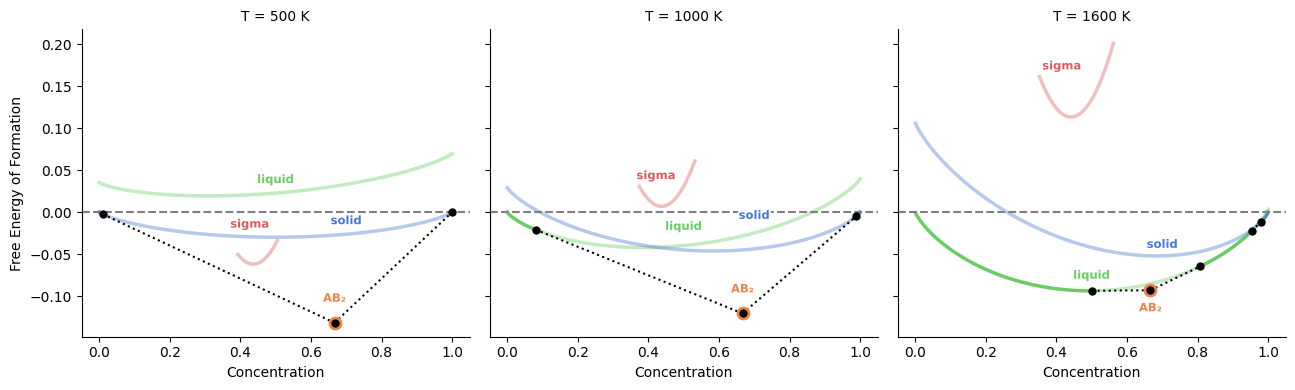

In [4]:
g = plot_excess_free_energy(
    df,
    convex_hull=True,
    height=4,
    aspect=1.1,
)